# Convention Speeches: Exploratory Data Analysis

This notebook provides a comprehensive visual exploration of the convention speeches dataset (2004-2024).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Party colors
PARTY_COLORS = {'Democratic': '#3498db', 'Republican': '#e74c3c'}

# Load data directly from CSV
speeches_df = pd.read_csv("../data/unified_speeches.csv")

print(f"Loaded {len(speeches_df):,} rows")
print(f"Unique speakers: {speeches_df['speaker'].nunique():,}")
print(f"Total words: {speeches_df['word_count'].sum():,}")
print(f"Years: {speeches_df['year'].min()}–{speeches_df['year'].max()}")
print(f"Columns: {list(speeches_df.columns)}")

Loaded 1,800 rows
Unique speakers: 1,353
Total words: 915,391
Years: 2004–2024
Columns: ['speaker', 'party', 'year', 'night', 'timestamp', 'speech', 'word_count', 'source_file', 'source']


## 1. Dataset Overview

In [2]:
# Convention summary
speeches_df.groupby(['year', 'party']).agg(
    speeches=('word_count', 'count'),
    unique_speakers=('speaker', 'nunique')
).reset_index()

,year,party,speeches,unique_speakers
0,2004,Democratic,183,181
1,2004,Republican,62,62
2,2008,Democratic,146,144
3,2008,Republican,69,65
4,2012,Democratic,131,128
5,2012,Republican,95,92
6,2016,Democratic,241,233
7,2016,Republican,78,76
8,2020,Democratic,347,309
9,2020,Republican,94,92


In [3]:
# Speeches per convention
convention_stats = speeches_df.groupby(['year', 'party']).agg(
    speeches=('word_count', 'count'),
    words=('word_count', 'sum'),
    unique_speakers=('speaker', 'nunique'),
    avg_speech_length=('word_count', 'mean')
).round(0).reset_index()

convention_stats

,year,party,speeches,words,unique_speakers,avg_speech_length
0,2004,Democratic,183,119456,181,653.0
1,2004,Republican,62,43614,62,703.0
2,2008,Democratic,146,85074,144,583.0
3,2008,Republican,69,49487,65,717.0
4,2012,Democratic,131,83092,128,634.0
5,2012,Republican,95,66798,92,703.0
6,2016,Democratic,241,114515,233,475.0
7,2016,Republican,78,63847,76,819.0
8,2020,Democratic,347,58195,309,168.0
9,2020,Republican,94,64861,92,690.0


## 2. Speech Counts Over Time

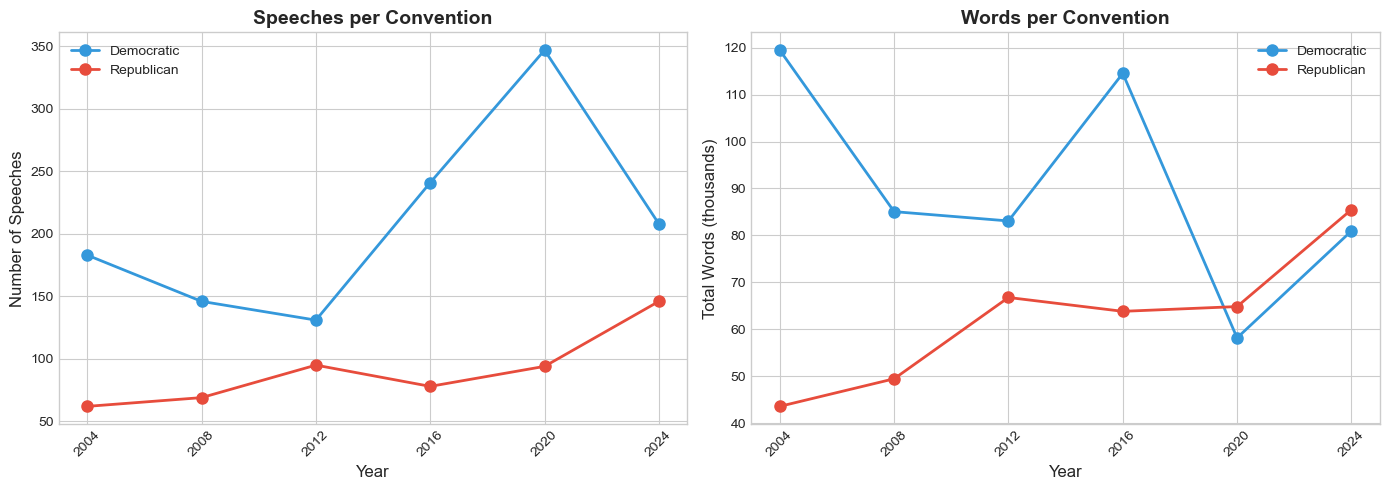

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speeches per convention
ax = axes[0]
for party in ['Democratic', 'Republican']:
    data = convention_stats[convention_stats['party'] == party]
    ax.plot(data['year'], data['speeches'], 'o-', label=party, 
            color=PARTY_COLORS[party], markersize=8, linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Speeches', fontsize=12)
ax.set_title('Speeches per Convention', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(convention_stats['year'].unique())
ax.tick_params(axis='x', rotation=45)

# Total words per convention
ax = axes[1]
for party in ['Democratic', 'Republican']:
    data = convention_stats[convention_stats['party'] == party]
    ax.plot(data['year'], data['words']/1000, 'o-', label=party,
            color=PARTY_COLORS[party], markersize=8, linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Words (thousands)', fontsize=12)
ax.set_title('Words per Convention', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(convention_stats['year'].unique())
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Speech Length Distribution

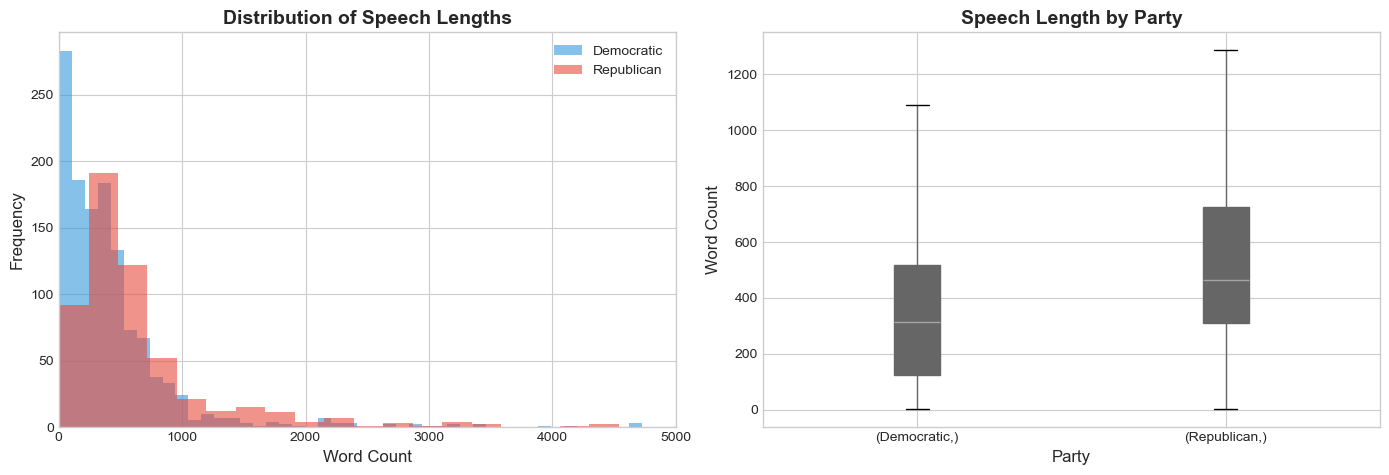

Speech length statistics:


,count,mean,std,min,25%,50%,75%,max
party,,,,,,,,
Democratic,1256.0,431.0,554.0,2.0,123.0,316.0,518.0,5248.0
Republican,544.0,688.0,851.0,3.0,311.0,466.0,725.0,11938.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of speech lengths
ax = axes[0]
for party in ['Democratic', 'Republican']:
    data = speeches_df[speeches_df['party'] == party]['word_count']
    ax.hist(data, bins=50, alpha=0.6, label=party, color=PARTY_COLORS[party])
ax.set_xlabel('Word Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Speech Lengths', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(0, 5000)

# Box plot by party and year
ax = axes[1]
speeches_df.boxplot(column='word_count', by=['party'], ax=ax, 
                    showfliers=False, patch_artist=True)
ax.set_xlabel('Party', fontsize=12)
ax.set_ylabel('Word Count', fontsize=12)
ax.set_title('Speech Length by Party', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Summary statistics
print("Speech length statistics:")
speeches_df.groupby('party')['word_count'].describe().round(0)

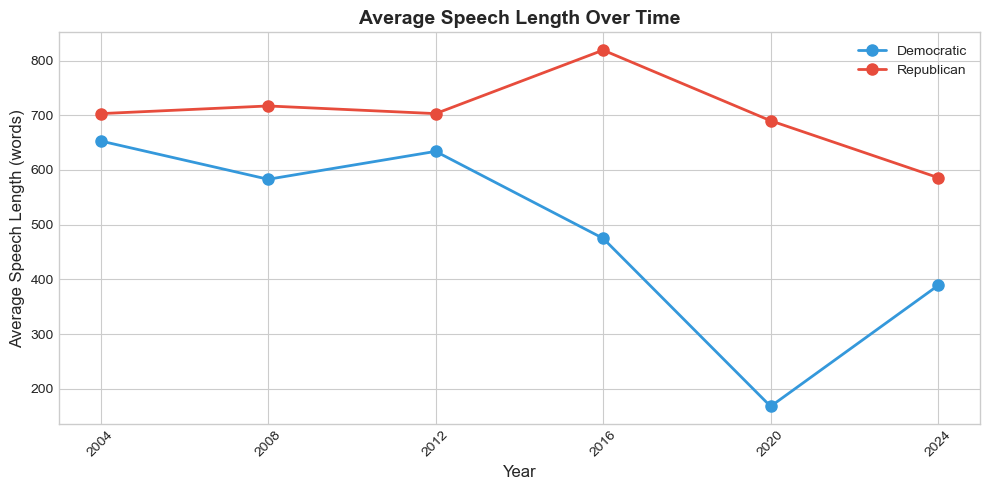

In [6]:
# Average speech length over time
fig, ax = plt.subplots(figsize=(10, 5))

for party in ['Democratic', 'Republican']:
    data = convention_stats[convention_stats['party'] == party]
    ax.plot(data['year'], data['avg_speech_length'], 'o-', label=party,
            color=PARTY_COLORS[party], markersize=8, linewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Speech Length (words)', fontsize=12)
ax.set_title('Average Speech Length Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(convention_stats['year'].unique())
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Top Speakers

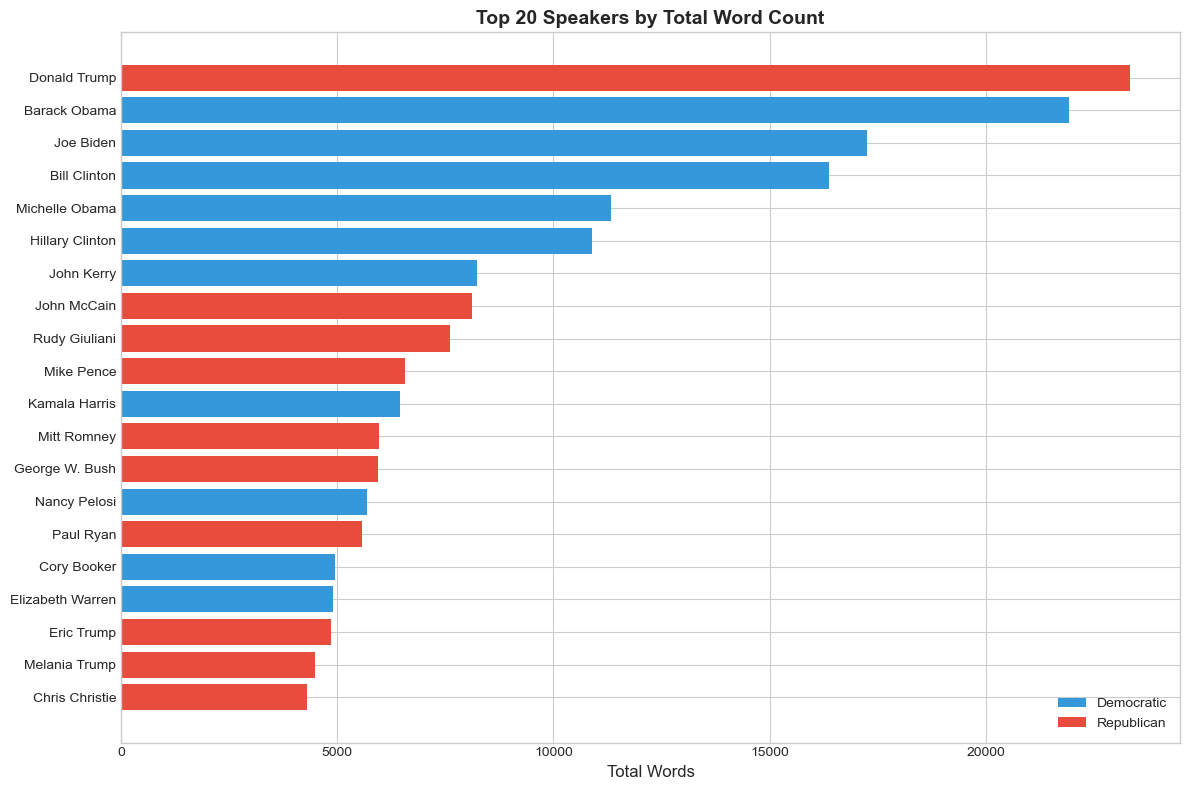

,speaker,party,total_words,num_speeches
0,Donald Trump,Republican,23326,4
1,Barack Obama,Democratic,21925,7
2,Joe Biden,Democratic,17264,9
3,Bill Clinton,Democratic,16372,6
4,Michelle Obama,Democratic,11325,7
5,Hillary Clinton,Democratic,10902,6
6,John Kerry,Democratic,8228,4
7,John McCain,Republican,8116,3
8,Rudy Giuliani,Republican,7611,4
9,Mike Pence,Republican,6569,2


In [7]:
# Top speakers by total word count
top_speakers = speeches_df.groupby(['speaker', 'party']).agg(
    total_words=('word_count', 'sum'),
    num_speeches=('word_count', 'count'),
    years=('year', lambda x: list(sorted(x.unique())))
).sort_values('total_words', ascending=False).head(20).reset_index()

fig, ax = plt.subplots(figsize=(12, 8))

colors = [PARTY_COLORS[p] for p in top_speakers['party']]
bars = ax.barh(range(len(top_speakers)), top_speakers['total_words'], color=colors)
ax.set_yticks(range(len(top_speakers)))
ax.set_yticklabels(top_speakers['speaker'])
ax.invert_yaxis()
ax.set_xlabel('Total Words', fontsize=12)
ax.set_title('Top 20 Speakers by Total Word Count', fontsize=14, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PARTY_COLORS['Democratic'], label='Democratic'),
                   Patch(facecolor=PARTY_COLORS['Republican'], label='Republican')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

top_speakers[['speaker', 'party', 'total_words', 'num_speeches']]

## 5. Data Sources

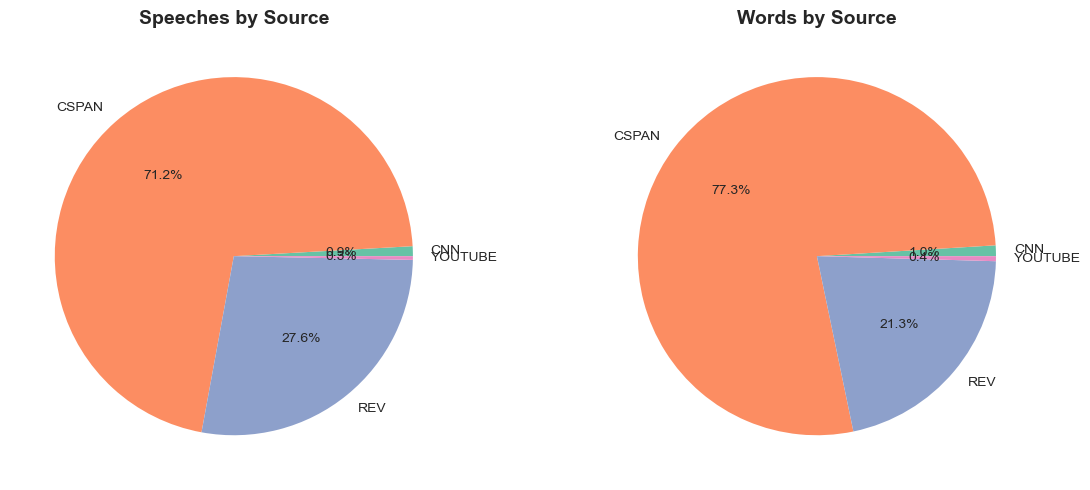

,source,speeches,words
0,CNN,16,8852
1,CSPAN,1282,707594
2,REV,496,194835
3,YOUTUBE,6,4110


In [8]:
# Source breakdown
source_stats = speeches_df.groupby('source').agg(
    speeches=('word_count', 'count'),
    words=('word_count', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Speeches by source
ax = axes[0]
ax.pie(source_stats['speeches'], labels=source_stats['source'], autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(source_stats)))
ax.set_title('Speeches by Source', fontsize=14, fontweight='bold')

# Words by source
ax = axes[1]
ax.pie(source_stats['words'], labels=source_stats['source'], autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(source_stats)))
ax.set_title('Words by Source', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

source_stats

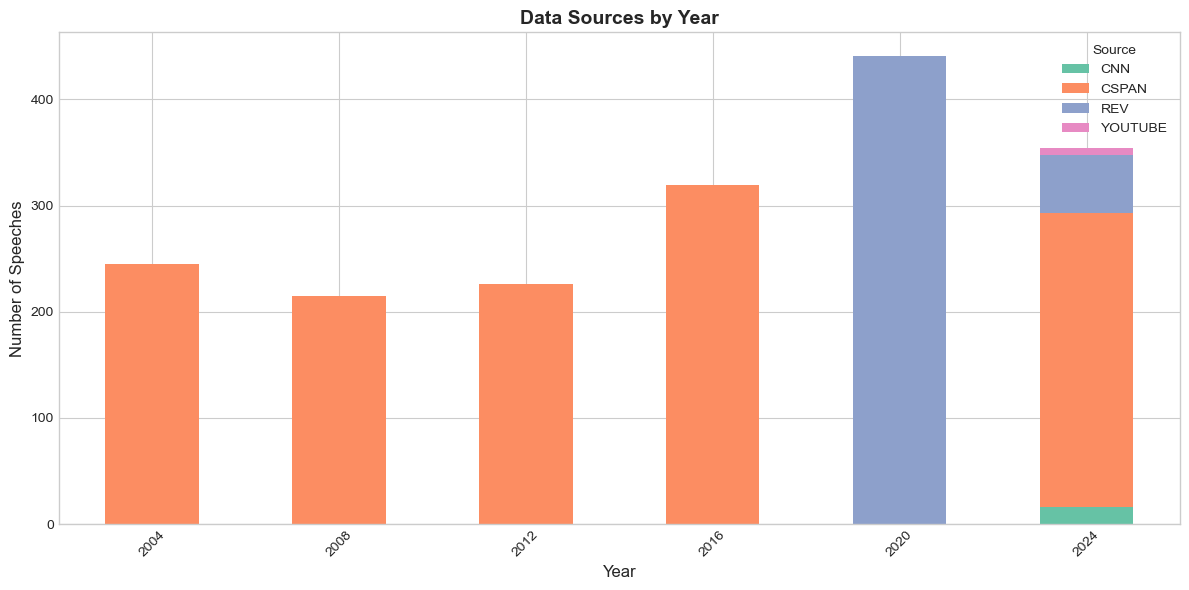

In [9]:
# Source by year
source_by_year = speeches_df.groupby(['year', 'source']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
source_by_year.plot(kind='bar', stacked=True, ax=ax, 
                    color=sns.color_palette('Set2', len(source_by_year.columns)))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Speeches', fontsize=12)
ax.set_title('Data Sources by Year', fontsize=14, fontweight='bold')
ax.legend(title='Source')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Speeches by Night

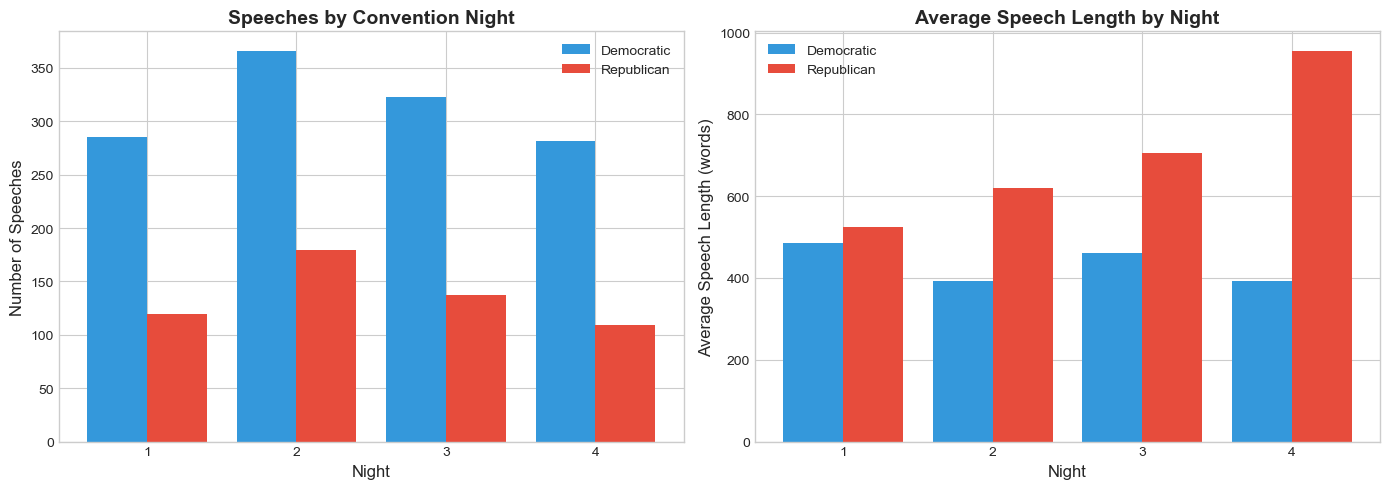

In [10]:
# Filter to speeches with night data
with_night = speeches_df[speeches_df['night'].notna() & (speeches_df['night'] > 0)].copy()

night_stats = with_night.groupby(['party', 'night']).agg(
    speeches=('word_count', 'count'),
    avg_length=('word_count', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speeches per night
ax = axes[0]
for party in ['Democratic', 'Republican']:
    data = night_stats[night_stats['party'] == party]
    ax.bar(data['night'] + (0.2 if party == 'Republican' else -0.2), 
           data['speeches'], width=0.4, label=party, color=PARTY_COLORS[party])
ax.set_xlabel('Night', fontsize=12)
ax.set_ylabel('Number of Speeches', fontsize=12)
ax.set_title('Speeches by Convention Night', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
ax.legend()

# Average length per night
ax = axes[1]
for party in ['Democratic', 'Republican']:
    data = night_stats[night_stats['party'] == party]
    ax.bar(data['night'] + (0.2 if party == 'Republican' else -0.2), 
           data['avg_length'], width=0.4, label=party, color=PARTY_COLORS[party])
ax.set_xlabel('Night', fontsize=12)
ax.set_ylabel('Average Speech Length (words)', fontsize=12)
ax.set_title('Average Speech Length by Night', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
ax.legend()

plt.tight_layout()
plt.show()

## 7. Heatmap: Speeches by Year and Party

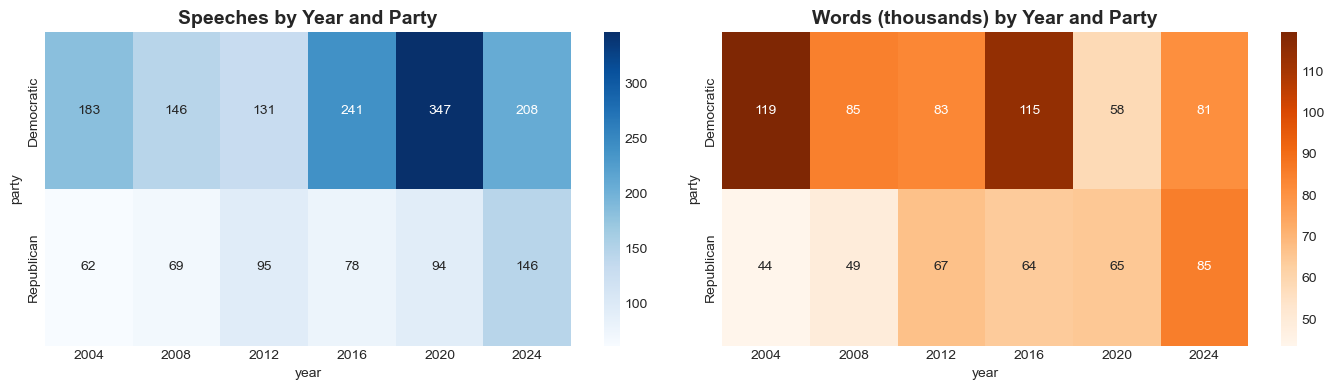

In [11]:
# Create pivot table
pivot_speeches = speeches_df.pivot_table(
    index='party', columns='year', values='word_count', aggfunc='count'
)

pivot_words = speeches_df.pivot_table(
    index='party', columns='year', values='word_count', aggfunc='sum'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Speeches heatmap
ax = axes[0]
sns.heatmap(pivot_speeches, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Speeches by Year and Party', fontsize=14, fontweight='bold')

# Words heatmap
ax = axes[1]
sns.heatmap(pivot_words/1000, annot=True, fmt='.0f', cmap='Oranges', ax=ax)
ax.set_title('Words (thousands) by Year and Party', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [12]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"\nTotal speeches: {len(speeches_df):,}")
print(f"Total words: {speeches_df['word_count'].sum():,}")
print(f"Unique speakers: {speeches_df['speaker'].nunique():,}")
print(f"Years covered: {speeches_df['year'].min()}-{speeches_df['year'].max()}")

print("\n--- By Party ---")
for party in ['Democratic', 'Republican']:
    data = speeches_df[speeches_df['party'] == party]
    print(f"\n{party}:")
    print(f"  Speeches: {len(data):,}")
    print(f"  Words: {data['word_count'].sum():,}")
    print(f"  Unique speakers: {data['speaker'].nunique():,}")
    print(f"  Avg speech length: {data['word_count'].mean():.0f} words")

print("\n--- Speech Length Percentiles ---")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p}th percentile: {speeches_df['word_count'].quantile(p/100):.0f} words")

DATASET SUMMARY

Total speeches: 1,800
Total words: 915,391
Unique speakers: 1,353
Years covered: 2004-2024

--- By Party ---

Democratic:
  Speeches: 1,256
  Words: 541,293
  Unique speakers: 928
  Avg speech length: 431 words

Republican:
  Speeches: 544
  Words: 374,098
  Unique speakers: 429
  Avg speech length: 688 words

--- Speech Length Percentiles ---
  25th percentile: 169 words
  50th percentile: 368 words
  75th percentile: 602 words
  90th percentile: 955 words
  95th percentile: 1486 words
  99th percentile: 3253 words


In [13]:
print("Notebook complete.")

Notebook complete.
